# Exploratory Data Analysis — VAB Predictive Maintenance

**Project:** Predictive maintenance of *Véhicules de l'Avant Blindé* (VAB) armoured vehicles  
**Goal:** Understand the dataset structure and key relationships before modelling  
**Features:** `km`, `condition`, `vehicle_age`, `num_revisions`, `engine_temperature`  
**Target:** `breakdown` (0 = No breakdown, 1 = Breakdown detected)

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

FEATURES = ['km', 'condition', 'vehicle_age', 'num_revisions', 'engine_temperature']
TARGET   = 'breakdown'
DATA_PATH = '../data/raw_data_vab.csv'

In [16]:
# Load data with fallback if CSV is absent
def load_data(path):
    try:
        df = pd.read_csv(path)
        print(f"Loaded from CSV: {df.shape}")
        return df
    except FileNotFoundError:
        print("CSV not found — generating fallback dataset (800 rows)")
        np.random.seed(42)
        n = 800
        age = np.random.randint(1, 31, n)
        km  = np.clip(age * 8000 + np.random.normal(0, 18000, n), 0, 500000).astype(int)
        condition = np.array([np.random.choice([0,1,2], p=[0.4,0.4,0.2] if a>20
                          else [0.2,0.4,0.4] if a>10 else [0.08,0.27,0.65])
                         for a in age])
        num_revisions = np.clip(age * 0.85 + np.random.normal(0, 3, n), 0, None).astype(int)
        engine_temperature = np.clip(np.where(condition==0,105,np.where(condition==1,90,76))
                         + np.random.normal(0, 8, n), 60, 140).astype(int)
        logit  = (-5.0 + 2.5*(km-km.min())/(km.max()-km.min())
                  + 1.8*(2-condition)/2 + 0.9*(age-1)/29
                  + 1.5*(engine_temperature-60)/80 - 0.6*num_revisions/num_revisions.max())
        breakdown = np.random.binomial(1, 1/(1+np.exp(-logit)), n)
        return pd.DataFrame({'id':range(101,101+n),'km':km,'condition':condition,
                             'vehicle_age':age,'num_revisions':num_revisions,
                             'engine_temperature':engine_temperature,'breakdown':breakdown})

df = load_data(DATA_PATH)

Loaded from CSV: (800, 7)


---
## 1. Dataset Overview

In [17]:
print(f"Shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes)
df.head()

Shape: (800, 7)

Data types:
id                    int64
km                    int64
condition             int64
vehicle_age           int64
num_revisions         int64
engine_temperature    int64
breakdown             int64
dtype: object


,id,km,condition,vehicle_age,num_revisions,engine_temperature,breakdown
0,101,63432,2,7,6,76,0
1,102,149852,2,20,22,64,0
2,103,217200,1,29,22,87,0
3,104,124386,1,15,13,89,0
4,105,92409,2,11,7,96,0


In [18]:
print("--- Descriptive Statistics ---")
df[FEATURES + [TARGET]].describe().round(2)

--- Descriptive Statistics ---


,km,condition,vehicle_age,num_revisions,engine_temperature,breakdown
count,800.00,800.00,800.00,800.00,800.00,800.00
mean,129235.19,1.19,16.00,13.17,87.00,0.14
std,75631.36,0.78,9.09,8.12,13.64,0.35
min,0.00,0.00,1.00,0.00,60.00,0.00
25%,59515.25,1.00,8.00,6.00,76.00,0.00
50%,132163.00,1.00,16.50,14.00,87.00,0.00
75%,195588.75,2.00,24.00,20.00,97.00,0.00
max,278320.00,2.00,30.00,32.00,120.00,1.00


In [5]:
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nDuplicates: {df.duplicated(subset=['id']).sum()}")

Missing values:
id                    0
km                    0
condition             0
vehicle_age           0
num_revisions         0
engine_temperature    0
breakdown             0
dtype: int64

Duplicates: 0


> **Note:** No missing values or duplicates in the synthetic dataset. The cleaning pipeline handles these cases if they appear in real data.

---
## 2. Univariate Distributions

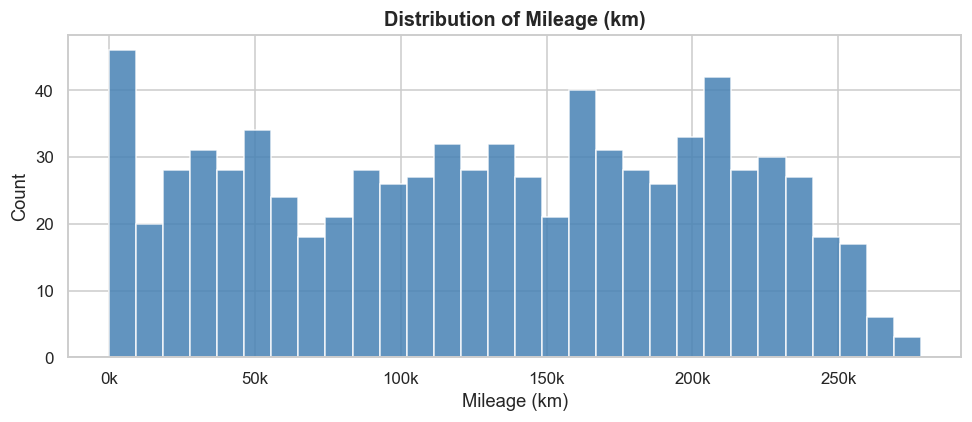

In [6]:
# km distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['km'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Distribution of Mileage (km)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mileage (km)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

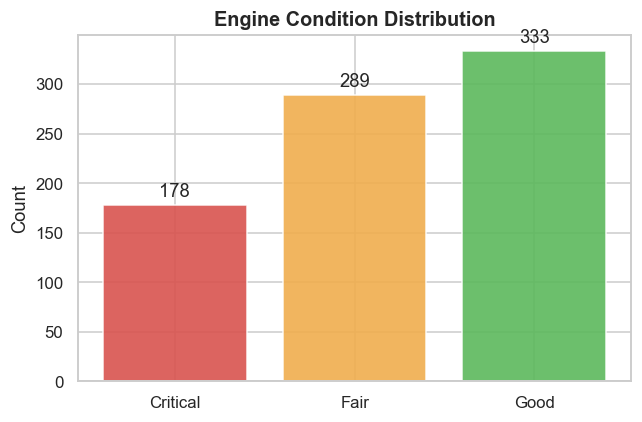

In [7]:
# condition distribution
fig, ax = plt.subplots(figsize=(6, 4))
labels = {0: 'Critical', 1: 'Fair', 2: 'Good'}
counts = df['condition'].value_counts().sort_index()
bars = ax.bar([labels[i] for i in counts.index], counts.values,
              color=['#d9534f','#f0ad4e','#5cb85c'], edgecolor='white', alpha=0.9)
ax.bar_label(bars, padding=3)
ax.set_title('Engine Condition Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

Breakdown rate (breakdown=1): 14.4%


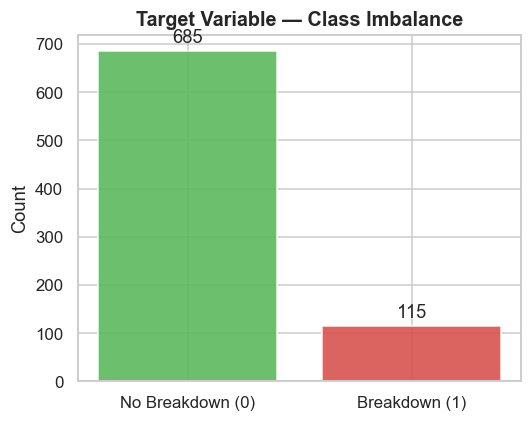

In [8]:
# breakdown class imbalance
breakdown_rate = df[TARGET].mean()
print(f"Breakdown rate (breakdown=1): {breakdown_rate:.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
counts_b = df[TARGET].value_counts()
bars = ax.bar(['No Breakdown (0)', 'Breakdown (1)'], counts_b[[0,1]].values,
              color=['#5cb85c','#d9534f'], edgecolor='white', alpha=0.9)
ax.bar_label(bars, padding=3)
ax.set_title('Target Variable — Class Imbalance', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

> **Class imbalance:** The dataset is imbalanced (~15% positive class), which is realistic for maintenance scenarios. Metrics like Precision, Recall, and F1-score are therefore more informative than raw Accuracy.

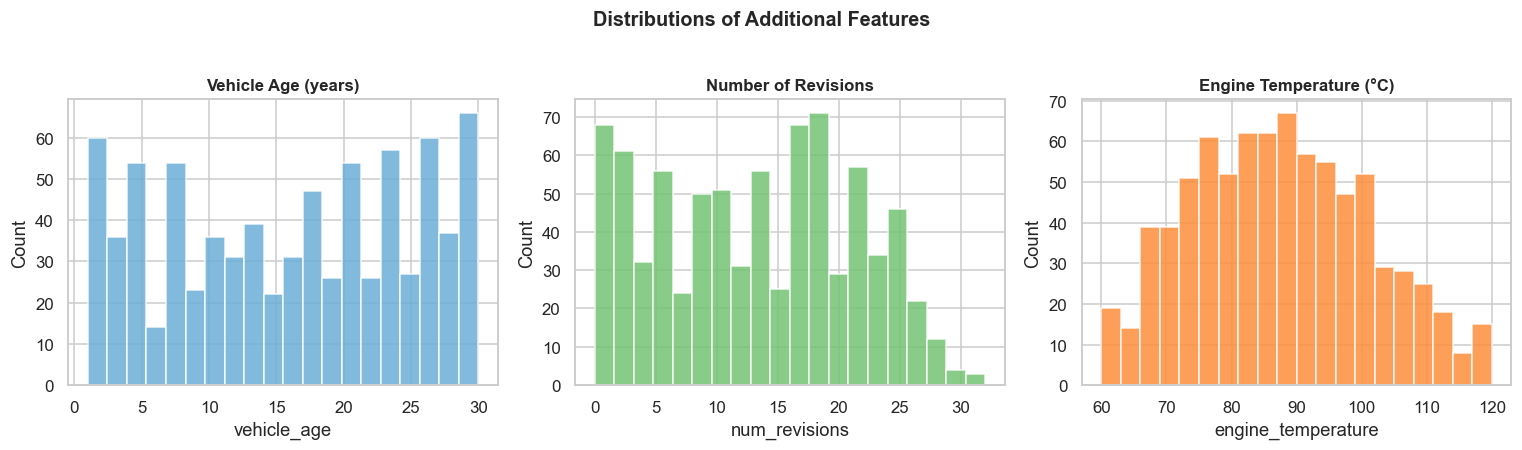

In [9]:
# Distributions of remaining numeric features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
num_cols = ['vehicle_age', 'num_revisions', 'engine_temperature']
titles   = ['Vehicle Age (years)', 'Number of Revisions', 'Engine Temperature (°C)']
colors   = ['#6baed6', '#74c476', '#fd8d3c']

for ax, col, title, color in zip(axes, num_cols, titles, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Distributions of Additional Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Bivariate Analysis — Features vs Target

/var/folders/hd/xhbr5l3x33z3hbcmt1c3lyzw0000gn/T/ipykernel_52644/3244005698.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='breakdown_label', y='km', palette=['#5cb85c','#d9534f'], ax=ax)


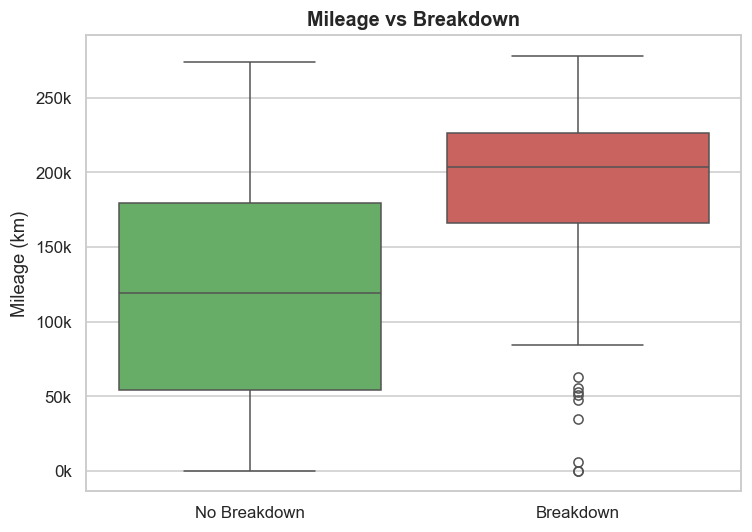

In [10]:
# km vs breakdown — boxplot
fig, ax = plt.subplots(figsize=(7, 5))
df_plot = df.copy()
df_plot['breakdown_label'] = df_plot[TARGET].map({0: 'No Breakdown', 1: 'Breakdown'})
sns.boxplot(data=df_plot, x='breakdown_label', y='km', palette=['#5cb85c','#d9534f'], ax=ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_title('Mileage vs Breakdown', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Mileage (km)')
plt.tight_layout()
plt.show()

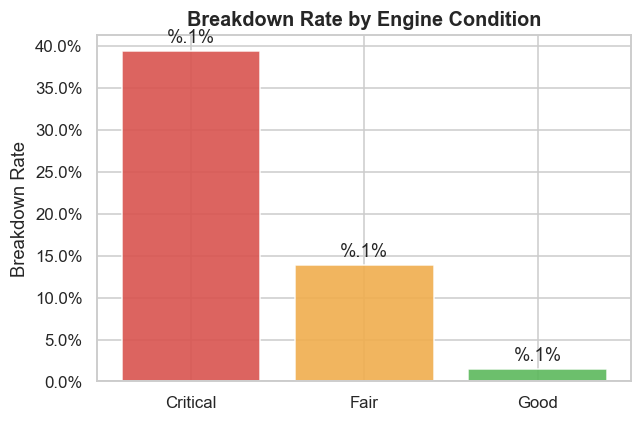

In [11]:
# condition vs breakdown — grouped bar (breakdown rate per condition)
breakdown_by_condition = df.groupby('condition')[TARGET].mean().reset_index()
breakdown_by_condition['condition_label'] = breakdown_by_condition['condition'].map({0:'Critical', 1:'Fair', 2:'Good'})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(breakdown_by_condition['condition_label'], breakdown_by_condition[TARGET],
              color=['#d9534f','#f0ad4e','#5cb85c'], edgecolor='white', alpha=0.9)
ax.bar_label(bars, fmt='%.1%', padding=3)
ax.set_title('Breakdown Rate by Engine Condition', fontsize=13, fontweight='bold')
ax.set_ylabel('Breakdown Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

/var/folders/hd/xhbr5l3x33z3hbcmt1c3lyzw0000gn/T/ipykernel_52644/3075350267.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='breakdown_label', y=col,
/var/folders/hd/xhbr5l3x33z3hbcmt1c3lyzw0000gn/T/ipykernel_52644/3075350267.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='breakdown_label', y=col,


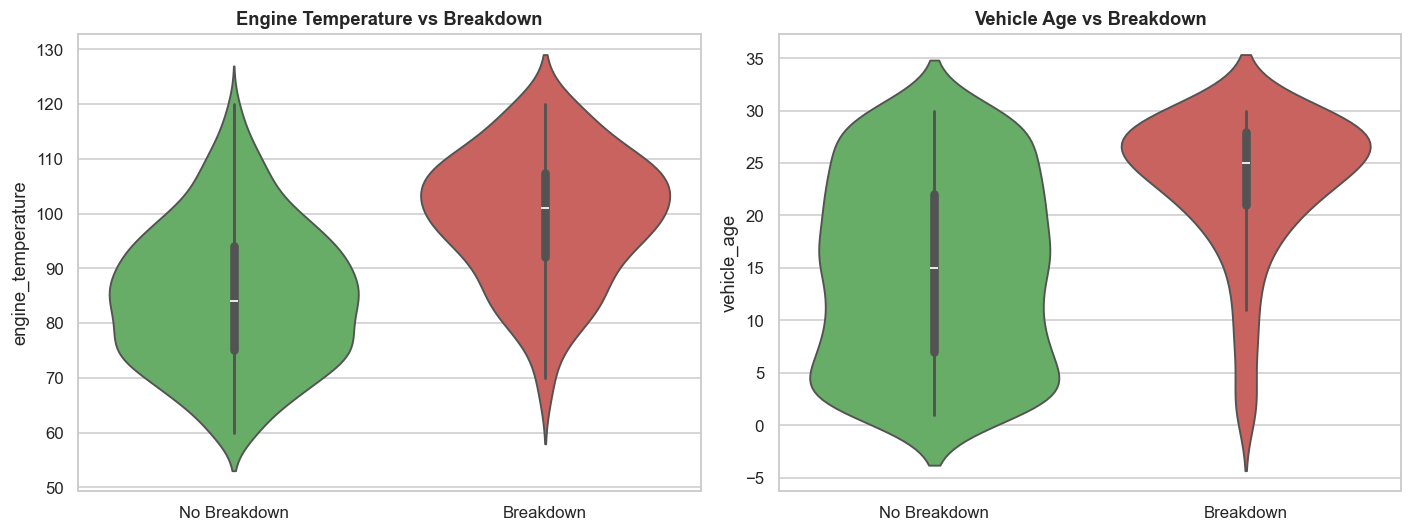

In [12]:
# engine_temperature and vehicle_age vs breakdown — violin plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(
    axes,
    ['engine_temperature', 'vehicle_age'],
    ['Engine Temperature vs Breakdown', 'Vehicle Age vs Breakdown']
):
    sns.violinplot(data=df_plot, x='breakdown_label', y=col,
                   palette=['#5cb85c','#d9534f'], inner='box', ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

> **Key observations:**
> - Vehicles with breakdowns have **higher mileage**, **lower engine condition** (more critical), **higher engine temperature**, and **older age** on average.
> - The breakdown rate for Critical-condition vehicles (~39%) is far above the overall rate (~14%), confirming `condition` is a strong predictor.

---
## 4. Correlation Analysis

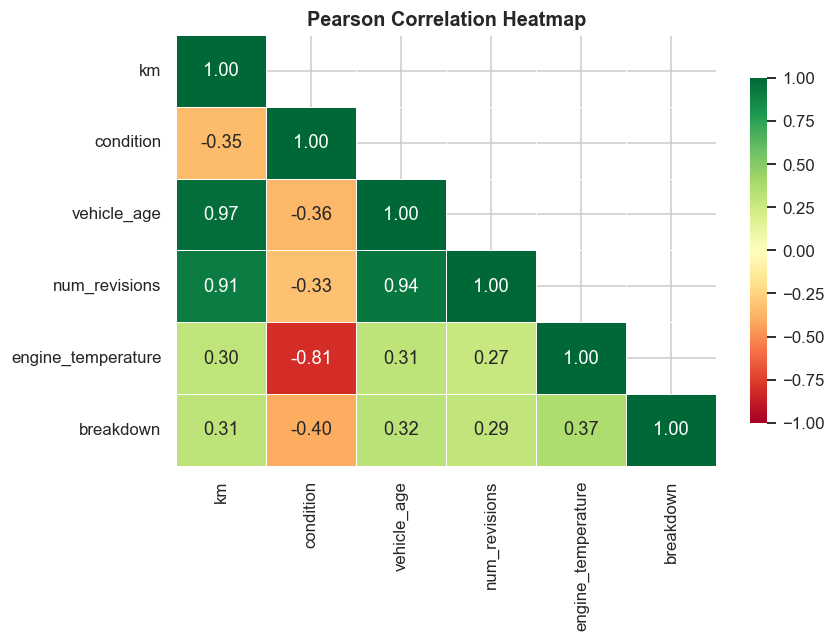

In [13]:
corr_matrix = df[FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # hide upper triangle

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Pearson Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Correlation with target only
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Correlations with 'breakdown' (sorted by absolute value):")
print(target_corr.round(3).to_string())

Correlations with 'breakdown' (sorted by absolute value):
condition            -0.401
engine_temperature    0.371
vehicle_age           0.316
km                    0.310
num_revisions         0.292


---
## 5. Key Findings

| Feature | Correlation with `breakdown` | Interpretation |
|---|---|---|
| `condition` | Negative (~−0.40) | Worse condition → higher breakdown risk |
| `engine_temperature` | Positive (~+0.37) | Higher temp → higher breakdown risk |
| `km` | Positive (~+0.31) | Higher mileage → higher breakdown risk |
| `vehicle_age` | Positive (~+0.25) | Older vehicle → higher breakdown risk |
| `num_revisions` | Slight positive | More revisions = older vehicles (collinear with age) |

**Modelling implications:**
- All 5 features carry predictive signal — use all of them.
- `condition` and `engine_temperature` are the strongest individual predictors.
- The ~14% positive class rate means Accuracy alone is misleading; favour F1-score, ROC-AUC and PR curves.
- On imbalanced data, Precision-Recall curves are more informative than ROC curves: the large number of true negatives inflates ROC-AUC, while PR curves focus mostly on the minority class (breakdowns).
- Logistic Regression will benefit from MinMax scaling; Random Forest is scale-invariant.

**Next step:** Run `scripts/model_comparison.py` to train and evaluate both models.